<img src="../../data/images/hiaoos_learning_moored.png" width="300" align="right">

# Load data - SBE37 instrument


In this notebook, we will:

- Explain how to **convert raw data** (`.hex`., `.XMLCON`) **to a physically readable data format** (`.cnv`).   
- **Load data** from a raw `.cnv` file obtained from an **Seabird SBE37** CTD.
- Have a **quick look** at the data and metadata.
- **Store the data as a NetCDF file** for subsequent use.

___

#### Imports 
We start with importing `kval.moored` which contains some helper functions for loading `.cnv` files.
- Data and metadata (including information about the instrument, searial number, etc) are read from the input file.
- Data and metadata are organized into our preferred format (`xarray` *Dataset*, which makes for easy data workflow, and excellent compatability with netCDF format).

In [16]:
from kval.data import moored
%matplotlib widget

___

## NOTE: `.cnv` files

This notebook starts from human-readable `.cnv` files, where raw data have been cnverted tpo physical values through existing calibration coefficients. `.cnv` files can be produced when reading data from the instrument using Seabird's *Seaterm* aquisition software (go to `Tools - Convert .XML data file`). 

In some cases, you may only have raw files (`.hex`., `.XMLCON`) available - in this case, you can convert to `.cnv` using the *SBE Data Processing* software [<sup id="fnref1"><a href="#fn1">1</a></sup>].

To convert files usig SBE Data Processing, use `Run -> Data Conversion`

> <sup id="fn1">1</sup>: *A newer alternative to SBEProcessing, *Fathom*, is now available. So too is a Python package from SeaBird, [seabirdscientific](https://github.com/Sea-BirdScientific/seabirdscientific). `kval` intends to use functionality from this package eventually, but this has not been implemented yet - feel free to experiment (but note that there does noe seem to be an easy way to digest `.XMLCON` files at this point). <a href="#fnref1">↩</a>


---





## Load data

Specify the file you want to load 

In [4]:
sbe37_file = '../../data/moored_CTD_test_data/raw_data/AT200_21_22_SBE37_15252_113m.cnv'

.. and load it into an xarray Dataset, `ds`:

In [6]:
ds = moored.load_moored(sbe37_file)

___

## Have a quick look at the data

We now have the data imported in to an xarray Dataset, with variables like `TIME`, `CNDC`, `TEMP`, `PRES`. We have also collected some useful metadata such as serial numbers, calibration dates, etc.

First, have a look at the contents of the data by executing `ds` (next cell). This will display an overview of ther dataset, including dimensions (in this case, 23903 points in the `TIME` dimension), variables, and metadata. 

Click around to get a sense of the contents of the dataset: 
- Click 📄 next to a variable to see its metadata
- Click ⛃ next top a variable to se a subset of the data.
- Global metadata attributes are found near the bottom, under *Attributes*

In [8]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:     (TIME: 31953)
Coordinates:
  * TIME        (TIME) float64 256kB 1.894e+04 1.894e+04 ... 1.927e+04 1.927e+04
Data variables:
    CNDC        (TIME) float64 256kB -0.007572 -0.007571 ... 37.01 37.21
    PRES        (TIME) float64 256kB -0.298 -0.311 -0.321 ... -0.421 -0.427
    PSAL        (TIME) float64 256kB 0.0 0.0 0.0 0.0 ... 34.28 34.22 34.14 34.18
    TEMP        (TIME) float64 256kB 3.957 3.987 3.96 ... 9.573 9.741 9.913
    timeM       (TIME) float64 256kB 15.0 30.0 45.0 ... 4.793e+05 4.793e+05
    timeH       (TIME) float64 256kB 0.25 0.5 0.75 ... 7.988e+03 7.988e+03
    TIME_JULD   (TIME) float64 256kB 312.0 312.0 312.0 ... 644.8 644.8 644.8
    SBE_FLAG    (TIME) float64 256kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    PROCESSING  object 8B None
Attributes:
    history:                   2021-11-07 - 2022-10-06: Data collection.\n202...
    instrument_model:          Sea-Bird SBE37SM-RS232
    instrument_serial_number:  15252
    time_coverage_resolution:  P0000-00-00T00:15:00

___

> **Note: Variables in the file**
> Depending on how the file was exported, your `.cnv` may contain different parameters; including derived variables like `PSAL` and other variables like `timeM`.
>
> The only variables that are necessary are `TIME` (which was parsed from one of the other time fields), and the variables the instrument, in this case: `PRES`, `TEMP`, and `CNDC`
>
> You can retain any variables you'd like, including salinity `PSAL`. We can also easily recompute it later.
>
____

In the folling line we willremove unused variables: 

In [12]:
ds = ds[['PRES', 'CNDC', 'TEMP']]

If we look at the updated dataset, it should only contain the core variables. 

In [14]:
ds

<xarray.Dataset> Size: 1MB
Dimensions:  (TIME: 31953)
Coordinates:
  * TIME     (TIME) float64 256kB 1.894e+04 1.894e+04 ... 1.927e+04 1.927e+04
Data variables:
    PRES     (TIME) float64 256kB -0.298 -0.311 -0.321 ... -0.415 -0.421 -0.427
    CNDC     (TIME) float64 256kB -0.007572 -0.007571 -0.007601 ... 37.01 37.21
    TEMP     (TIME) float64 256kB 3.957 3.987 3.96 4.003 ... 9.573 9.741 9.913
Attributes:
    history:                   2021-11-07 - 2022-10-06: Data collection.\n202...
    instrument_model:          Sea-Bird SBE37SM-RS232
    instrument_serial_number:  15252
    time_coverage_resolution:  P0000-00-00T00:15:00

___

### Quick look continued
We now have the data on our preferred format, and can make some quicl plots using `xarray`..

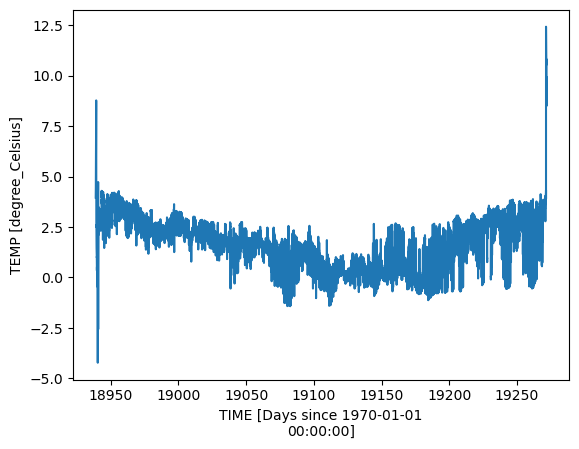

In [15]:
ds.TEMP.plot()

.. or use functionality from `kval` which lets us flip thropugh variables and show e.g. temporal averages *(but may not work on all systems)*:

In [17]:
moored.plot(ds)

____

***So -*** we have now read the data with some basic metadata and gotten a basic dea of what it contains. We can now export directly to a NetCDF file. 

In subsequent notebooks, we will load the file we create here and go on to do some post-processing and analysis, and we will save new updated versionsof the data as we go.
___

## Save to NetCDF

In [20]:
# Specify where we want to save the file to
out_path = '../../data/moored_CTD_test_data/intermediate_data/'

# Specify a file name
out_name = 'AT200_21_22_SBE37_15252_113m_from_raw.nc'

___

**All done!** Hopefully this produced a file - check that it was created where you expected it to.
___

Note that you can also export to other formats, e.g. a MATLAB data file:

    moored.to_mat(ds, 'path/dataset_as_mat.mat)

Here, we will stick with NetCDF.